In [7]:
import numpy as np
import pandas as pd
import gymnasium as gym
from functools import partial
from sklearn.model_selection import ParameterSampler
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from stable_baselines3.common.evaluation import evaluate_policy

from industrial_inventory_env import IndustrialInventoryEnv, generate_student_config

ROLL_NUMBER = "DA25M622"
student_config = generate_student_config(ROLL_NUMBER)

def make_env_fn(scenario_mode="random", domain_rand=True):
    return IndustrialInventoryEnv(
        student_config=student_config,
        scenario_mode=scenario_mode,
        domain_randomization=domain_rand,
    )

In [2]:
# Parameter distributions inspired by RL-Zoo PPO discrete & control suites
param_distributions = {
    "learning_rate": [1e-4, 2.5e-4, 3e-4, 5e-4, 7.5e-4],
    "n_steps": [64, 128, 256, 512],              # Rollout steps per env
    "batch_size": [64, 128, 256],                # Minibatch size (must divide n_steps * n_envs)
    "n_epochs": [5, 10, 15],                     # Surrogate optimization epochs
    "gamma": [0.95, 0.98, 0.99, 0.995],          # Multi-day lead-time planning horizon
    "gae_lambda": [0.85, 0.90, 0.95, 0.98],
    "clip_range": [0.1, 0.2, 0.3],
    "ent_coef": [0.001, 0.005, 0.01, 0.02],     # Essential: forces order exploration across [11, 11, 11]
    "vf_coef": [0.25, 0.5, 0.75],
    "max_grad_norm": [0.5, 0.7, 1.0],
    "net_arch": [
        dict(pi=[128, 128], vf=[128, 128]),
        dict(pi=[256, 256], vf=[256, 256]),
    ]
}

def evaluate_candidate(params, n_training_steps=100000, n_eval_episodes=20):
    # Ensure batch_size evenly divides total buffer size (n_steps * n_envs)
    n_envs = 8
    total_buffer = params["n_steps"] * n_envs
    if total_buffer % params["batch_size"] != 0:
        params["batch_size"] = params["n_steps"]  # Safe fallback

    train_env = make_vec_env(
        partial(make_env_fn, scenario_mode="random", domain_rand=True),
        n_envs=n_envs,
        seed=2026,
        vec_env_cls=DummyVecEnv
    )
    train_env = VecMonitor(train_env)

    eval_env = make_vec_env(
        partial(make_env_fn, scenario_mode="random", domain_rand=True),
        n_envs=4,
        seed=42,
        vec_env_cls=DummyVecEnv
    )
    eval_env = VecMonitor(eval_env)

    model = PPO(
        policy="MultiInputPolicy",
        env=train_env,
        learning_rate=params["learning_rate"],
        n_steps=params["n_steps"],
        batch_size=params["batch_size"],
        n_epochs=params["n_epochs"],
        gamma=params["gamma"],
        gae_lambda=params["gae_lambda"],
        clip_range=params["clip_range"],
        ent_coef=params["ent_coef"],
        vf_coef=params["vf_coef"],
        max_grad_norm=params["max_grad_norm"],
        policy_kwargs=dict(net_arch=params["net_arch"]),
        verbose=0,
        seed=2026,
    )

    model.learn(total_timesteps=n_training_steps)
    
    mean_reward, std_reward = evaluate_policy(
        model, eval_env, n_eval_episodes=n_eval_episodes, deterministic=True
    )
    
    # Environment daily reward = -daily_cost / 100 => 50 steps per episode
    # Mean episode cost is approx: -100 * mean_reward
    estimated_cost = -mean_reward * 100.0

    train_env.close()
    eval_env.close()
    return estimated_cost, model

In [3]:
# Run Random Search across parameter space
N_ITER = 12
sampler = ParameterSampler(param_distributions, n_iter=N_ITER, random_state=2026)

best_cost = float("inf")
best_params = None
best_model = None

for i, sampled_params in enumerate(sampler):
    print(f"\n--- [Iteration {i+1}/{N_ITER}] Testing Parameters ---")
    print({k: v for k, v in sampled_params.items() if k != "net_arch"})
    
    try:
        eval_cost, candidate_model = evaluate_candidate(
            sampled_params, n_training_steps=80000, n_eval_episodes=15
        )
        print(f"Resulting Mean Eval Cost: {eval_cost:,.2f}")
        
        if eval_cost < best_cost:
            best_cost = eval_cost
            best_params = sampled_params
            best_model = candidate_model
            best_model.save("ppo_inventory_best_searched")
            print(f">>> New best found: {best_cost:,.2f}")
    except Exception as e:
        print(f"Run failed: {e}")

print("\n" + "="*50)
print(f"Optimal Evaluated Cost: {best_cost:,.2f}")
print("Optimal Hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


--- [Iteration 1/12] Testing Parameters ---
{'vf_coef': 0.75, 'n_steps': 256, 'n_epochs': 10, 'max_grad_norm': 0.7, 'learning_rate': 0.00075, 'gamma': 0.99, 'gae_lambda': 0.95, 'ent_coef': 0.01, 'clip_range': 0.1, 'batch_size': 256}


/home/sohang/Projects/iit-madras-web-mtech-ai/trimester3/DA6002W_Online&ReinforcementLearning/ReinforcementLearning/RL_ProjectCompetition/RL_Student_Package_2026/.venv-sb3-torch213/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Resulting Mean Eval Cost: 494,992.19
>>> New best found: 494,992.19

--- [Iteration 2/12] Testing Parameters ---
{'vf_coef': 0.5, 'n_steps': 512, 'n_epochs': 5, 'max_grad_norm': 1.0, 'learning_rate': 0.0005, 'gamma': 0.98, 'gae_lambda': 0.98, 'ent_coef': 0.005, 'clip_range': 0.1, 'batch_size': 64}


/home/sohang/Projects/iit-madras-web-mtech-ai/trimester3/DA6002W_Online&ReinforcementLearning/ReinforcementLearning/RL_ProjectCompetition/RL_Student_Package_2026/.venv-sb3-torch213/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Resulting Mean Eval Cost: 1,202,529.88

--- [Iteration 3/12] Testing Parameters ---
{'vf_coef': 0.75, 'n_steps': 128, 'n_epochs': 10, 'max_grad_norm': 0.5, 'learning_rate': 0.0003, 'gamma': 0.995, 'gae_lambda': 0.95, 'ent_coef': 0.005, 'clip_range': 0.1, 'batch_size': 64}
Resulting Mean Eval Cost: 352,436.16
>>> New best found: 352,436.16

--- [Iteration 4/12] Testing Parameters ---
{'vf_coef': 0.75, 'n_steps': 64, 'n_epochs': 5, 'max_grad_norm': 0.5, 'learning_rate': 0.00025, 'gamma': 0.99, 'gae_lambda': 0.85, 'ent_coef': 0.01, 'clip_range': 0.2, 'batch_size': 128}
Resulting Mean Eval Cost: 153,118.83
>>> New best found: 153,118.83

--- [Iteration 5/12] Testing Parameters ---
{'vf_coef': 0.75, 'n_steps': 64, 'n_epochs': 5, 'max_grad_norm': 0.5, 'learning_rate': 0.0005, 'gamma': 0.99, 'gae_lambda': 0.98, 'ent_coef': 0.02, 'clip_range': 0.2, 'batch_size': 64}
Resulting Mean Eval Cost: 673,476.50

--- [Iteration 6/12] Testing Parameters ---
{'vf_coef': 0.25, 'n_steps': 256, 'n_epochs': 1

copied from above output:

```
Optimal Evaluated Cost: 114,070.34
Optimal Hyperparameters:
  vf_coef: 0.75
  net_arch: {'pi': [128, 128], 'vf': [128, 128]}
  n_steps: 512
  n_epochs: 10
  max_grad_norm: 0.7
  learning_rate: 0.00025
  gamma: 0.99
  gae_lambda: 0.9
  ent_coef: 0.01
  clip_range: 0.3
  batch_size: 64
```


In [4]:
loaded_model = PPO.load("ppo_inventory_best_searched")

In [8]:
records = []
env = make_env_fn()
observation, info = env.reset(seed=101)
while True:
    action, _ = loaded_model.predict(observation, deterministic=True)  # MultiDiscrete indices directly
    observation, reward, terminated, truncated, info = env.step(action)
    records.append({
        "action": action,
        "reward": reward,
        "truncated": truncated,
        "info": info,
        'day': info['day'],
        **info['costs']
    })
    if terminated or truncated:
        break

df = pd.DataFrame(records)
df

,action,reward,truncated,info,day,holding,stockout,ordering,discarding,daily_total,episode_total
0,"[3, 2, 2]",-28.250,False,"{'day': 0, 'demand': [25, 21, 28], 'fulfilled_...",0,2425.0,0.0,400.0,0.0,2825.0,2825.0
1,"[3, 2, 0]",-20.850,False,"{'day': 1, 'demand': [23, 19, 34], 'fulfilled_...",1,1805.0,0.0,280.0,0.0,2085.0,4910.0
2,"[4, 2, 3]",-15.150,False,"{'day': 2, 'demand': [33, 30, 28], 'fulfilled_...",2,1115.0,0.0,400.0,0.0,1515.0,6425.0
3,"[4, 3, 3]",-40.100,False,"{'day': 3, 'demand': [36, 26, 20], 'fulfilled_...",3,810.0,2800.0,400.0,0.0,4010.0,10435.0
4,"[3, 3, 3]",-15.350,False,"{'day': 4, 'demand': [23, 21, 34], 'fulfilled_...",4,1135.0,0.0,400.0,0.0,1535.0,11970.0
5,"[2, 3, 3]",-14.175,False,"{'day': 5, 'demand': [27, 43, 37], 'fulfilled_...",5,1017.5,0.0,400.0,0.0,1417.5,13387.5
6,"[2, 3, 3]",-15.900,False,"{'day': 6, 'demand': [19, 30, 35], 'fulfilled_...",6,1190.0,0.0,400.0,0.0,1590.0,14977.5
7,"[2, 3, 6]",-15.275,False,"{'day': 7, 'demand': [25, 35, 35], 'fulfilled_...",7,1127.5,0.0,400.0,0.0,1527.5,16505.0
8,"[2, 3, 3]",-17.800,False,"{'day': 8, 'demand': [33, 24, 21], 'fulfilled_...",8,1380.0,0.0,400.0,0.0,1780.0,18285.0
9,"[2, 3, 1]",-17.125,False,"{'day': 9, 'demand': [29, 30, 27], 'fulfilled_...",9,1312.5,0.0,400.0,0.0,1712.5,19997.5


<Axes: >

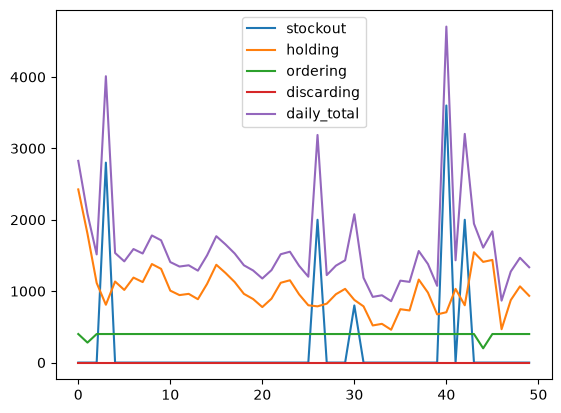

In [10]:
df[['stockout', 'holding', 'ordering', 'discarding', 'daily_total']].plot()